## Unzip Dataset

In [1]:
!unzip -q "/content/drive/MyDrive/YOLO/widerface_yolo_format.zip" -d /content/

## Preprocess the dataset

In [2]:
# 1: Install dependencies
!pip install -q tensorflow opencv-python

import os
import glob
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt

# 2: Constants
IMAGE_SIZE = 224
GRID_SIZE = 7
BOXES_PER_CELL = 2
NUM_CLASSES = 1
BATCH_SIZE = 8
EPOCHS = 20

# 3: Parsing function for YOLO labels
def parse_function(img_path, label_path):
    img_path = img_path.numpy().decode()
    label_path = label_path.numpy().decode()

    # Load and preprocess image
    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
    img = img / 255.0

    # Load label
    label = np.zeros((GRID_SIZE, GRID_SIZE, 5 * BOXES_PER_CELL + NUM_CLASSES), dtype=np.float32)
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                c, x, y, w, h = map(float, line.strip().split())
                grid_x = int(x * GRID_SIZE)
                grid_y = int(y * GRID_SIZE)

                # Assign to one anchor box
                label[grid_y, grid_x, 0:5] = [x, y, w, h, 1]
                label[grid_y, grid_x, 5:] = [1]

    return img.astype(np.float32), label

# 4: TensorFlow wrapper
def tf_parse(img_path, label_path):
    img, label = tf.py_function(parse_function, [img_path, label_path], [tf.float32, tf.float32])
    img.set_shape([IMAGE_SIZE, IMAGE_SIZE, 3])
    label.set_shape([GRID_SIZE, GRID_SIZE, 5 * BOXES_PER_CELL + NUM_CLASSES])
    return img, label

# 5: Dataset loader
def get_dataset(image_dir, label_dir):
    image_paths = sorted(glob.glob(os.path.join(image_dir, '*.jpg')))
    label_paths = [os.path.join(label_dir, os.path.basename(p).replace('.jpg', '.txt')) for p in image_paths]

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, label_paths))
    dataset = dataset.map(tf_parse, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.shuffle(512).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return dataset

# 6: Load train/val sets
train_dataset = get_dataset('/content/widerface_yolo_format/images/train', '/content/widerface_yolo_format/labels/train')
val_dataset = get_dataset('/content/widerface_yolo_format/images/val', '/content/widerface_yolo_format/labels/val')


## Defining Model

In [3]:
def yolo_v1_model():
    inputs = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    x = layers.Conv2D(64, (7,7), strides=2, padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(192, (3,3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(128, (1,1), activation='relu')(x)
    x = layers.Conv2D(256, (3,3), padding='same', activation='relu')(x)
    x = layers.Conv2D(256, (1,1), activation='relu')(x)
    x = layers.Conv2D(512, (3,3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(GRID_SIZE * GRID_SIZE * (5 * BOXES_PER_CELL + NUM_CLASSES))(x)
    outputs = layers.Reshape((GRID_SIZE, GRID_SIZE, 5 * BOXES_PER_CELL + NUM_CLASSES))(x)
    return Model(inputs, outputs)

model = yolo_v1_model()
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 112, 112, 64)   │         9,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 56, 56, 192)    │       110,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 28, 28, 192)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 256)    │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 539)            │       552,475 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 11)       │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,763,867 (10.54 MB)

 Trainable params: 2,763,867 (10.54 MB)

 Non-trainable params: 0 (0.00 B)

## Loss, Compile and Train

In [4]:
# Simple MSE loss (can improve later)
def yolo_loss(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))

model.compile(optimizer='adam', loss=yolo_loss)

# Train the model
model.fit(train_dataset,
          validation_data=val_dataset,
          epochs=EPOCHS)

# Save trained model
model.save("yolo_face_model.h5")


Epoch 1/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 143s 81ms/step - loss: 0.0578 - val_loss: 0.0591
Epoch 2/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 123s 74ms/step - loss: 0.0576 - val_loss: 0.0592
Epoch 3/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 126s 77ms/step - loss: 0.0577 - val_loss: 0.0592
Epoch 4/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 140s 75ms/step - loss: 0.0577 - val_loss: 0.0591
Epoch 5/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 141s 75ms/step - loss: 0.0578 - val_loss: 0.0591
Epoch 6/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 125s 76ms/step - loss: 0.0576 - val_loss: 0.0591
Epoch 7/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 141s 75ms/step - loss: 0.0576 - val_loss: 0.0590
Epoch 8/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 127s 77ms/step - loss: 0.0580 - val_loss: 0.0590
Epoch 9/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 124s 75ms/step - loss: 0.0579 - val_loss: 0.0591
Epoch 10/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 126s 77ms/step - loss: 0.0579 - val_loss: 0.0591
Epoch 11/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 139s 75ms/step - loss: 0.0580 - val_loss: 0.05

In [12]:
model.evaluate(val_dataset)

404/404 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - loss: 0.0535


0.059047166258096695

## Predict on Test Image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


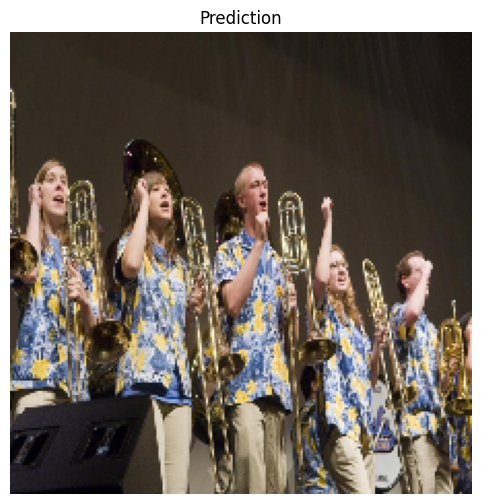

In [13]:
def predict_and_plot(image_path):
    image = cv2.imread(image_path)
    image_resized = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
    input_img = image_resized / 255.0
    input_img = np.expand_dims(input_img, axis=0)

    pred = model.predict(input_img)[0]  # shape: (7,7,11)
    image_display = cv2.cvtColor(image_resized, cv2.COLOR_BGR2RGB)

    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            cell = pred[i, j]
            conf = cell[4]
            if conf > 0.4:
                x, y, w, h = cell[0:4]
                x *= IMAGE_SIZE
                y *= IMAGE_SIZE
                w *= IMAGE_SIZE
                h *= IMAGE_SIZE

                xmin = int(x - w/2)
                ymin = int(y - h/2)
                xmax = int(x + w/2)
                ymax = int(y + h/2)

                cv2.rectangle(image_display, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)

    plt.figure(figsize=(6,6))
    plt.imshow(image_display)
    plt.axis('off')
    plt.title("Prediction")
    plt.show()

# Example usage
predict_and_plot('/content/widerface_yolo_format/images/val/44.jpg')
